# Exploring MLflow 3 Scoring Capabilities for LLM Development

This notebook focuses on the new scoring capabilities introduced in **MLflow 3**, with an emphasis on the **development cycle** — how evaluation scores are generated and used for **offline analysis** of LLM outputs.

## Objectives

- Understand how MLflow 3 creates and manages evaluation scores for LLM-generated responses.  
- Explore offline evaluation workflows to benchmark LLM judges (automatic evaluators) against human-labeled or ground-truth outcomes.  

## What We’ll Do

- Walk through the process of generating scores for sample LLM responses.  
- Perform offline comparisons between LLM judge outputs and human or ground-truth evaluations.  
- Analyze and visualize deviations between automated and human judgments to assess reliability and potential biases.   

## Why It Matters  

This analysis highlights how to design and trust scoring pipelines during the **LLM development lifecycle**, enabling more robust evaluation, governance, and iteration of models.

In [0]:
# Install or upgrade mlflow to 3.0.0 or above
%pip install --upgrade "mlflow[databricks]>=3.1.0" openai

# Restart the Python kernel to ensure newly installed packages are recognized
dbutils.library.restartPython()

In [0]:
# Core libraries
import time
import json
from typing import List, Dict, Any, cast

# Data handling
import pandas as pd

# MLflow core functionality
import mlflow
import mlflow.genai.datasets
from mlflow.entities import Document

# MLflow GenAI scorers and judges for evaluation
from mlflow.genai.scorers import (
    RetrievalGroundedness,
    RelevanceToQuery,
    Safety,
    Guidelines,
    scorer,  # Base scorer function
)
from mlflow.genai.judges import make_judge  # Custom judgment logic

# OpenAI integration
from openai import OpenAI  # For interacting with OpenAI's models

# Databricks integration
from databricks.connect import DatabricksSession  # For connecting to Databricks via Python API

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='mlflow')

In [0]:
# Replace with a Unity Catalog schema where you have CREATE TABLE permission
uc_schema = "kyra_wulffert.email_agent"

Sets up a GenAI pipeline that generates personalized sales emails using a simulated CRM database.

In [0]:
# Enable automatic MLflow tracing of OpenAI API calls for experiment tracking
mlflow.openai.autolog()

# Get current MLflow credentials for Databricks (reuse for OpenAI-style API access)
mlflow_creds = mlflow.utils.databricks_utils.get_databricks_host_creds()

# Set up OpenAI-compatible client for Databricks-hosted LLMs
client = OpenAI(
    api_key=mlflow_creds.token,
    base_url=f"{mlflow_creds.host}/serving-endpoints"
)

# Simulated CRM database containing customer info, meeting notes, support tickets, etc.
CRM_DATA = {
    "Acme Corp": {
        "contact_name": "Alice Chen",
        "recent_meeting": "Product demo on Monday, very interested in enterprise features. They asked about: advanced analytics, real-time dashboards, API integrations, custom reporting, multi-user support, SSO authentication, data export capabilities, and pricing for 500+ users",
        "support_tickets": [
            "Ticket #123: API latency issue (resolved last week)",
            "Ticket #124: Feature request for bulk import",
            "Ticket #125: Question about GDPR compliance"
        ],
        "account_manager": "Sarah Johnson"
    },
    "TechStart": {
        "contact_name": "Bob Martinez",
        "recent_meeting": "Initial sales call last Thursday, requested pricing",
        "support_tickets": [
            "Ticket #456: Login issues (open - critical)",
            "Ticket #457: Performance degradation reported",
            "Ticket #458: Integration failing with their CRM"
        ],
        "account_manager": "Mike Thompson"
    },
    "Global Retail": {
        "contact_name": "Carol Wang",
        "recent_meeting": "Quarterly review yesterday, happy with platform performance",
        "support_tickets": [],
        "account_manager": "Sarah Johnson"
    }
}

# This function retrieves customer-related documents from CRM_DATA and wraps them as MLflow Document objects
@mlflow.trace(span_type="RETRIEVER")  # Enables tracing for RetrievalGroundedness scoring
def retrieve_customer_info(customer_name: str) -> List[Document]:
    """Retrieve structured customer information from the simulated CRM database."""
    if customer_name in CRM_DATA:
        data = CRM_DATA[customer_name]
        return [
            Document(
                id=f"{customer_name}_meeting",
                page_content=f"Recent meeting: {data['recent_meeting']}",
                metadata={"type": "meeting_notes"}
            ),
            Document(
                id=f"{customer_name}_tickets",
                page_content=f"Support tickets: {', '.join(data['support_tickets']) if data['support_tickets'] else 'No open tickets'}",
                metadata={"type": "support_status"}
            ),
            Document(
                id=f"{customer_name}_contact",
                page_content=f"Contact: {data['contact_name']}, Account Manager: {data['account_manager']}",
                metadata={"type": "contact_info"}
            )
        ]
    return []

# This function generates a personalized sales email using retrieved CRM data and user-provided instructions
@mlflow.trace  # Enables full MLflow tracking of the model call
def generate_sales_email(customer_name: str, user_instructions: str) -> Dict[str, str]:
    """Generate a sales follow-up email based on customer data and sales rep instructions."""
    # Retrieve context from CRM
    customer_docs = retrieve_customer_info(customer_name)

    # Merge all retrieved content into one string to use as context in the prompt
    context = "\n".join([doc.page_content for doc in customer_docs])

    # Construct the LLM prompt
    prompt = f"""You are a sales representative. Based on the customer information below,
    write a brief follow-up email that addresses their request.

    Customer Information:
    {context}

    User instructions: {user_instructions}

    Keep the email concise and personalized."""

    # Generate response from the LLM hosted on Databricks (Claude 3 Sonnet in this case)
    response = client.chat.completions.create(
        model="databricks-claude-3-7-sonnet",  # Replace with e.g. "gpt-4o" if using OpenAI directly
        messages=[
            {"role": "system", "content": "You are a helpful sales assistant."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=2000
    )

    # Return the generated email content
    return {"email": response.choices[0].message.content}

# Run a test email generation for "Acme Corp" with specific user instructions
result = generate_sales_email("Acme Corp", "Follow up after product demo")

# Print the generated email to the notebook output
print(result["email"])

# Follow-Up Email

Subject: Following Up on Our Monday Product Demo - Enterprise Features

Dear Alice,

Thank you for attending our product demonstration on Monday. I'm Sarah Johnson, your dedicated Account Manager, and I wanted to follow up on the enterprise features we discussed.

I've compiled information on the specific areas you inquired about:
- Advanced analytics and real-time dashboards
- API integrations (noting your resolved latency issue from Ticket #123)
- Custom reporting and multi-user support
- SSO authentication and data export capabilities
- Pricing options for your 500+ user requirement

Additionally, I've noted your interest in bulk import functionality (Ticket #124) and have forwarded your GDPR compliance questions (Ticket #125) to our security team.

Would you be available for a brief call this week to discuss these items in more detail and address any remaining questions?

Best regards,

Sarah Johnson
Account Manager
[Contact Information]


Trace(trace_id=tr-0092ba69f1c8290e06cbb2ceeb75790a)

## How to register a prompt

In [0]:
# Register Prompt
initial_template = """You are a sales representative. Based on the customer information below,
    write a brief follow-up email that addresses their request.

    Customer Information:
    {{context}}

    User instructions: {{user_instructions}}

    Keep the email concise and personalized."""

# This table will be created in the UC schema specified in the previous line
prompt_name = "email_prompt"

# Register a new prompt
prompt = mlflow.genai.register_prompt(
    name=f"{uc_schema}.{prompt_name}",
    template=initial_template,
    # all parameters below are optional
    commit_message="Initial version of email prompt",
    tags={
        "task": "email_generation",
        "language": "en",
        "model_compatibility": "gpt-4"
    }
)

print(f"Created prompt '{prompt.name}' (version {prompt.version})")

Created prompt 'kyra_wulffert.email_agent.email_prompt' (version 8)


## Create an evaluation dataset from traces

In [0]:
# Simulate beta testing traffic with scenarios designed to fail guidelines
test_requests = [
    {"customer_name": "Acme Corp", "user_instructions": "Follow up after product demo"},
    {"customer_name": "TechStart", "user_instructions": "Check on support ticket status"},
    {"customer_name": "Global Retail", "user_instructions": "Send quarterly review summary"},
    {"customer_name": "Acme Corp", "user_instructions": "Write a very detailed email explaining all our product features, pricing tiers, implementation timeline, and support options"},
    {"customer_name": "TechStart", "user_instructions": "Send an enthusiastic thank you for their business!"},
    {"customer_name": "Global Retail", "user_instructions": "Send a follow-up email"},
    {"customer_name": "Acme Corp", "user_instructions": "Just check in to see how things are going"},
]

# Run requests and capture traces
print("Simulating production traffic...")
for req in test_requests:
    try:
        result = generate_sales_email(**req)
        print(f"✓ Generated email for {req['customer_name']}")
    except Exception as e:
        print(f"✗ Error for {req['customer_name']}: {e}")

Simulating production traffic...
✓ Generated email for Acme Corp
✓ Generated email for TechStart
✓ Generated email for Global Retail
✓ Generated email for Acme Corp
✓ Generated email for TechStart
✓ Generated email for Global Retail
✓ Generated email for Acme Corp


[Trace(trace_id=tr-8931d09b93465f5a5ae8016f116b9fa2), Trace(trace_id=tr-dec3673aad035558e2a81b9da2ac2913), Trace(trace_id=tr-73b72c72487f4118dc9707297cf6312c), Trace(trace_id=tr-3254124b5cdb7b3cc3703132c3d26b98), Trace(trace_id=tr-6f0478d642d11833c0463c2653813cf7), Trace(trace_id=tr-b2940d02e4e9067129e1f6f33ad452a5), Trace(trace_id=tr-cdd78151bfaaea13061eaffd4a085cc4)]

Create an evaluation dataset based on the ingested traces

In [0]:
# Create an evaluation dataset using trace

# This table will be created in the above UC schema
evaluation_dataset_table_name = "email_generation_eval_"

try:
    eval_dataset = mlflow.genai.datasets.get_dataset(
    name=f"{uc_schema}.{evaluation_dataset_table_name}"
    )
    print(f"Loaded evaluation dataset: {uc_schema}.{evaluation_dataset_table_name}")
except:
    eval_dataset = mlflow.genai.datasets.create_dataset(
        name=f"{uc_schema}.{evaluation_dataset_table_name}"    )
    print(f"Created evaluation dataset: {uc_schema}.{evaluation_dataset_table_name}")

# Search for the simulated production traces,  get traces from the last 20 minutes with our trace name.
ten_minutes_ago = int((time.time() - 10 * 60) * 1000)

traces = mlflow.search_traces(
    filter_string=f"attributes.timestamp_ms > {ten_minutes_ago} AND "
                 f"attributes.status = 'OK' AND "
                 f"tags.`mlflow.traceName` = 'generate_sales_email'",
    order_by=["attributes.timestamp_ms DESC"]
)

print(f"Found {len(traces)} successful traces from beta test")

# Add the traces to the evaluation dataset
eval_dataset.merge_records(traces)
print(f"Added {len(traces)} records to evaluation dataset")

# Preview the dataset
eval_dataset_df = eval_dataset.to_df()
print(f"\nDataset preview:")
print(f"Total records: {len(eval_dataset_df)}")
print("\nSample record:")
sample = eval_dataset_df.iloc[0]
print(f"Inputs: {sample['inputs']}")

Loaded evaluation dataset: kyra_wulffert.email_agent.email_generation_eval_
Found 8 successful traces from beta test
Added 8 records to evaluation dataset

Dataset preview:
Total records: 7

Sample record:
Inputs: {'customer_name': 'Acme Corp', 'user_instructions': 'Write a very detailed email explaining all our product features, pricing tiers, implementation timeline, and support options'}


## Evaluate with LLM judges

There are multiple ways to create judges for LLM evaluation, including **Guidelines judges**, which express rules in natural language, and **Custom prompt judges**, which use custom-designed prompts to evaluate responses.

In [0]:
# Custom prompt for evaluating the tone and professionalism of generated emails
import litellm
litellm._turn_on_debug()
email_tone_prompt = """
You are an expert email communication analyst. Evaluate the tone and professionalism of the given email response.

EMAIL TO EVALUATE: {{response}}

CUSTOMER CONTEXT: {{context}}

EVALUATION CRITERIA:
1. Professional tone appropriate for B2B communication
2. Empathy and understanding of customer situation
3. Confidence without being pushy
4. Appropriate urgency based on account health
5. Language that builds trust and partnership

INSTRUCTIONS:
- Analyze the email tone across all 5 criteria
- Consider the customer's account health and situation
- Choose the most appropriate tone assessment

You must choose one of the following categories:

[[excellent]]: Perfectly calibrated tone for the situation - professional, empathetic, confident, appropriately urgent, and trust-building
[[good]]: Professional and appropriate tone with minor room for improvement
[[acceptable]]: Neutral/acceptable tone that meets basic professional standards
[[poor]]: Inappropriate tone (too casual, pushy, insensitive, or unprofessional)
"""
# Create the tone analysis judge
@scorer
def is_tone_good(inputs: Dict[Any, Any], outputs: Dict[Any, Any]):
    # we directly return the Feedback object from the guidelines LLM judge, but we could have post-processed it before returning it.
    tone_judge = make_judge(
        name="email_tone_analysis",
        prompt_template=email_tone_prompt,
        numeric_values={
            "excellent": 5,
            "good": 4,
            "acceptable": 3,
            "poor": 1
        }
    )

    return tone_judge(
        response=outputs.get("email", ""),
        context=inputs.get("user_instructions", ""),
        )


# Define a list of scorers for evaluating generated sales emails
email_scorers = [
        Guidelines(
            name="follows_instructions",
            guidelines="The generated email must follow the user_instructions in the request."
        ),
        Guidelines(
            name="concise_communication",
            guidelines="The email MUST be concise and to the point. The email should communicate the key message efficiently without being overly brief or losing important context."
        ),
        Guidelines(
            name="mentions_contact_name",
            guidelines="The email MUST explicitly mention the customer contact's first name (e.g., Alice, Bob, Carol) in the greeting. Generic greetings like 'Hello' or 'Dear Customer' are not acceptable."
        ),
        Guidelines(
            name="professional_tone",
            guidelines="The email must be in a professional tone."
        ),
        Guidelines(
            name="includes_next_steps",
            guidelines="The email MUST end with a specific, actionable next step that includes a concrete timeline."
        ),
        RelevanceToQuery(),  # Checks if email addresses the user's request
        Safety(),  # Checks for harmful or inappropriate content,
        is_tone_good,  # Custom tone evaluation defined above
    ]

# Run evaluation with predefined scorers
with mlflow.start_run(run_name="v1"):
    eval_results_v1 = mlflow.genai.evaluate(
    data=eval_dataset_df,
    predict_fn=generate_sales_email,
    scorers=email_scorers,
    )

2025/11/26 13:03:12 INFO mlflow.genai.utils.data_validation: Testing model prediction with the first sample in the dataset. To disable this check, set the MLFLOW_GENAI_EVAL_SKIP_TRACE_VALIDATION environment variable to True.


Evaluating:   0%|          | 0/7 [Elapsed: 00:00, Remaining: ?] 

If we want to assess the judges themselves using an evaluation dataset, how can we compare their performance?

## Improve your agent based on the evaluation

In [0]:
# Enhanced version of the email generator with stricter instruction-following
@mlflow.trace
def generate_sales_email_v2(customer_name: str, user_instructions: str) -> Dict[str, str]:
    """Generate personalized sales email based on customer data & a sale's rep's instructions."""
    # Retrieve customer information
    customer_docs = retrieve_customer_info(customer_name)

    if not customer_docs:
        return {"error": f"No customer data found for {customer_name}"}

    # Combine retrieved context
    context = "\n".join([doc.page_content for doc in customer_docs])

    # Generate email using retrieved context with better instruction following
    prompt = f"""You are a sales representative writing an email.

MOST IMPORTANT: Follow these specific user instructions exactly:
{user_instructions}

Customer context (only use what's relevant to the instructions):
{context}

Guidelines:
1. PRIORITIZE the user instructions above all else
2. Keep the email CONCISE - only include information directly relevant to the user's request
3. End with a specific, actionable next step that includes a concrete timeline (e.g., "I'll follow up with pricing by Friday" or "Let's schedule a 15-minute call this week")
4. Only reference customer information if it's directly relevant to the user's instructions

Write a brief, focused email that satisfies the user's exact request."""

    response = client.chat.completions.create(
        model="databricks-claude-3-7-sonnet",
        messages=[
            {"role": "system", "content": "You are a helpful sales assistant who writes concise, instruction-focused emails."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=2000
    )

    return {"email": response.choices[0].message.content}

# Test the application
result = generate_sales_email("Acme Corp", "Follow up after product demo")
print(result["email"])

# Follow-up Email: Product Demo

Dear Alice,

Thank you for attending our product demo on Monday. I'm Sarah Johnson, your dedicated Account Manager, and I wanted to follow up on your interest in our enterprise features.

I've compiled information addressing your specific inquiries about advanced analytics, real-time dashboards, API integrations, custom reporting, multi-user support, SSO authentication, and data export capabilities. I've also prepared a custom pricing proposal for your 500+ user requirement.

I'm pleased to confirm that the API latency issue (Ticket #123) has been fully resolved. Regarding your other tickets, our development team is currently working on the bulk import feature request (Ticket #124), and I've attached comprehensive documentation addressing your GDPR compliance questions (Ticket #125).

Would you be available for a brief call this week to discuss next steps? I'd be happy to arrange a technical session with our integration specialists if you'd like to dive

Trace(trace_id=tr-aa2de8b875504855b2341e450190d6fe)

### Register the new prompt template

In [0]:
new_template = """You are a sales representative writing an email.

MOST IMPORTANT: Follow these specific user instructions exactly:
{{user_instructions}}

Customer context (only use what's relevant to the instructions):
{{context}}

Guidelines:
1. PRIORITIZE the user instructions above all else
2. Keep the email CONCISE - only include information directly relevant to the user's request
3. End with a specific, actionable next step that includes a concrete timeline (e.g., "I'll follow up with pricing by Friday" or "Let's schedule a 15-minute call this week")
4. Only reference customer information if it's directly relevant to the user's instructions

Write a brief, focused email that satisfies the user's exact request."""

# Register a new version
updated_prompt = mlflow.genai.register_prompt(
    name=f"{uc_schema}.{prompt_name}",
    template=new_template,
    commit_message="Added detailed instructions for better output quality",
    tags={
        "improvement": "Added specific guidelines for summary quality"
    }
)

print(f"Created version {updated_prompt.version} of '{updated_prompt.name}'")

Created version 9 of 'kyra_wulffert.email_agent.email_prompt'


### Compare results with previous experiment run

In [0]:
# Run evaluation of the new version with the same scorers as before
with mlflow.start_run(run_name="v2"):
    eval_results_v2 = mlflow.genai.evaluate(
        data=eval_dataset_df, # same eval dataset
        predict_fn=generate_sales_email_v2, # new app version
        scorers=email_scorers, # same scorers as step 4
    )

2025/11/26 13:04:23 INFO mlflow.genai.utils.data_validation: Testing model prediction with the first sample in the dataset. To disable this check, set the MLFLOW_GENAI_EVAL_SKIP_TRACE_VALIDATION environment variable to True.


Evaluating:   0%|          | 0/7 [Elapsed: 00:00, Remaining: ?] 

In [0]:
# Fetch runs separately since mlflow.search_runs doesn't support IN or OR operators
run_v1_df = mlflow.search_runs(
    filter_string=f"run_id = '{eval_results_v1.run_id}'"
)
run_v2_df = mlflow.search_runs(
    filter_string=f"run_id = '{eval_results_v2.run_id}'"
)

# Extract metric columns (they end with /mean, not .aggregate_score)
# Skip the agent metrics (latency, token counts) for quality comparison
metric_cols = [col for col in run_v1_df.columns
               if col.startswith('metrics.') and col.endswith('/mean')
               and 'agent/' not in col]

# Create comparison table
comparison_data = []
for metric in metric_cols:
    metric_name = metric.replace('metrics.', '').replace('/mean', '')
    v1_score = run_v1_df[metric].iloc[0]
    v2_score = run_v2_df[metric].iloc[0]
    improvement = v2_score - v1_score

    comparison_data.append({
        'Metric': metric_name,
        'V1 Score': f"{v1_score:.3f}",
        'V2 Score': f"{v2_score:.3f}",
        'Improvement': f"{improvement:+.3f}",
        'Improved': '✓' if improvement >= 0 else '✗'
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

avg_v1 = run_v1_df[metric_cols].mean(axis=1).iloc[0]
avg_v2 = run_v2_df[metric_cols].mean(axis=1).iloc[0]
display(f"Overall average improvement: {(avg_v2 - avg_v1):+.3f} ({((avg_v2/avg_v1 - 1) * 100):+.1f}%)")

Metric,V1 Score,V2 Score,Improvement,Improved
safety,1.000,1.000,+0.000,✓
professional_tone,1.000,0.857,-0.143,✗
concise_communication,0.000,0.143,+0.143,✓
follows_instructions,0.286,0.714,+0.429,✓
includes_next_steps,0.000,0.571,+0.571,✓
mentions_contact_name,0.857,0.571,-0.286,✗
relevance_to_query,0.714,0.857,+0.143,✓


'Overall average improvement: +0.122 (+22.2%)'

## Evaluate Scorers with different LLMs

In [0]:
Sample_judge_data=[
    {
        "inputs": {
            "customer_name": "TechStart",
            "user_instructions": "Send an enthusiastic thank you for their business!"
        },
        "outputs": {
            "email": "# Thank You for Your Business!\n\nHi Bob,\n\nThank you so much for choosing to work with us! We're absolutely thrilled to have you on board and can't wait to support your success.\n\nYour business means a great deal to us, and we're committed to providing you with exceptional service every step of the way.\n\nI'll follow up with the pricing details you requested by end of day tomorrow.\n\nBest regards,\nMike Thompson"
        }
    },
    {
        "inputs": {
            "customer_name": "Global Retail",
            "user_instructions": "Send a follow-up email"
        },
        "outputs": {
            "email": "# Follow-Up Email\n\nHi Carol,\n\nThank you for your time during our quarterly review yesterday. I'm glad to hear you're happy with the platform performance.\n\nWould you like to schedule a brief call next week to discuss any additional ways we can support your team this quarter?\n\nI'm available Tuesday or Thursday afternoon if that works for you.\n\nBest regards,\nSarah Johnson"
        }
    },
    {
        "inputs": {
            "customer_name": "Acme Corp",
            "user_instructions": "Just check in to see how things are going"
        },
        "outputs": {
            "email": "# Subject: Quick Check-In\n\nHi Alice,\n\nJust checking in to see how things are going since our product demo on Monday.\n\nIs there anything you need from me at this point?\n\nI'm available if you have any questions about the enterprise features we discussed.\n\nBest,\nSarah"
        }
    }
]

In [0]:
from collections import OrderedDict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define which judge LLMs to try. Replace URIs with models available in your workspace/provider setup.
JUDGE_MODELS = OrderedDict([
    ("gpt-oss-120b", "databricks:/databricks-gpt-oss-120b"),
    ("gpt-oss-20b", "databricks:/databricks-gpt-oss-20b"),
    ("claude-sonnet-4", "databricks:/databricks-claude-sonnet-4"),
    ("Databricks default", None),  # None = use scorer defaults (often Databricks-managed)
])


Defines SCORER_FACTORIES, an OrderedDict mapping scorer names to factory functions.
Each factory creates a scorer to evaluate generated emails on criteria such as
groundedness, instruction adherence, conciseness, recipient naming, tone,
next steps, relevance, and safety.

In [0]:
from collections import OrderedDict

SCORER_FACTORIES = OrderedDict([
    ("RetrievalGroundedness", lambda m: RetrievalGroundedness(model=m) if m else RetrievalGroundedness()),

    ("Guidelines_follows_instructions", lambda m: Guidelines(
        name="follows_instructions",
        guidelines="The generated email must follow the user_instructions in the request.",
        model=m,
    ) if m else Guidelines(
        name="follows_instructions",
        guidelines="The generated email must follow the user_instructions in the request.",
    )),

    ("Guidelines_concise_communication", lambda m: Guidelines(
        name="concise_communication",
        guidelines="The email MUST be concise and to the point. The email should communicate the key message efficiently without being overly brief or losing important context.",
        model=m,
    ) if m else Guidelines(
        name="concise_communication",
        guidelines="The email MUST be concise and to the point. The email should communicate the key message efficiently without being overly brief or losing important context.",
    )),

    ("Guidelines_mentions_contact_name", lambda m: Guidelines(
        name="mentions_contact_name",
        guidelines="The email MUST explicitly mention the customer contact's first name (e.g., Alice, Bob, Carol) in the greeting. Generic greetings like 'Hello' or 'Dear Customer' are not acceptable.",
        model=m,
    ) if m else Guidelines(
        name="mentions_contact_name",
        guidelines="The email MUST explicitly mention the customer contact's first name (e.g., Alice, Bob, Carol) in the greeting. Generic greetings like 'Hello' or 'Dear Customer' are not acceptable.",
    )),

    ("Guidelines_professional_tone", lambda m: Guidelines(
        name="professional_tone",
        guidelines="The email must be in a professional tone.",
        model=m,
    ) if m else Guidelines(
        name="professional_tone",
        guidelines="The email must be in a professional tone.",
    )),

    ("Guidelines_includes_next_steps", lambda m: Guidelines(
        name="includes_next_steps",
        guidelines="The email MUST end with a specific, actionable next step that includes a concrete timeline.",
        model=m,
    ) if m else Guidelines(
        name="includes_next_steps",
        guidelines="The email MUST end with a specific, actionable next step that includes a concrete timeline.",
    )),

    ("RelevanceToQuery", lambda m: RelevanceToQuery(model=m) if m else RelevanceToQuery()),

    ("Safety", lambda m: Safety(model=m) if m else Safety()),
])

Evaluates multiple judge models against predefined benchmarks.
For each model, it runs all scorers, compares results to target metrics,
normalizes differences, computes an overall score, and aggregates results
into a combined DataFrame.

In [0]:
# Define your benchmark (example values)
benchmark = {
    'agent/latency_seconds/mean': 0.0,   # want no latency penalty
    'safety/mean': 0.8,
    'includes_next_steps/mean': 0.5,
    'mentions_contact_name/mean': 1.0,
    'professional_tone/mean': 0.5,
    'concise_communication/mean': 1.0,
    'email_tone_analysis/mean': 5.0,
    'follows_instructions/mean': 0.5,
    'relevance_to_query/mean': 1.0
}

# Define maximum possible values for normalization
max_possible = {
    'agent/latency_seconds/mean': 1.0,  # assume scaled (if not, adjust)
    'safety/mean': 1.0,
    'includes_next_steps/mean': 1.0,
    'mentions_contact_name/mean': 1.0,
    'professional_tone/mean': 1.0,
    'concise_communication/mean': 1.0,
    'email_tone_analysis/mean': 5.0,
    'follows_instructions/mean': 1.0,
    'relevance_to_query/mean': 1.0
}

all_comparisons = []

for judge_name, judge_uri in JUDGE_MODELS.items():
    with mlflow.start_run(run_name=f"judge:{judge_name}"):
        mlflow.set_tags({"judge_model": judge_uri})

        # run all scorers for this judge
        scorers = [factory(judge_uri) for factory in SCORER_FACTORIES.values()]
        result = mlflow.genai.evaluate(
            data=Sample_judge_data,
            scorers=scorers,
        )

        # Remove latency
        metrics_to_compare = {k: v for k, v in result.metrics.items() if k != 'agent/latency_seconds/mean'}

        # Compare results to benchmark
        comparison = {}
        scores = []

        for metric, actual in metrics_to_compare.items():
            target = benchmark[metric]
            abs_diff = abs(actual - target)
            norm_score = 1 - (abs_diff / max_possible[metric])
            comparison[metric] = {
                "actual": actual,
                "benchmark": target,
                "abs_diff": abs_diff,
                "norm_score": norm_score,
            }
            scores.append(norm_score)

        # Compute overall closeness
        overall_score = sum(scores) / len(scores) * 100
        comparison["overall"] = {
            "actual": overall_score,
            "benchmark": 100.0,
            "abs_diff": 100.0 - overall_score,
            "norm_score": overall_score / 100.0,
        }

        # Store comparison for this judge
        df_comparison = pd.DataFrame(comparison).T
        df_comparison["judge_model"] = judge_name  # add as a column

        all_comparisons.append(df_comparison)

# Combine all into one big table
df_all = pd.concat(all_comparisons)

# Reset index for readability
df_all = df_all.reset_index().rename(columns={"index": "metric"})

print(df_all)

2025/11/26 13:07:30 INFO mlflow.genai.scorers.validation: The input data is missing following columns that are required by the specified scorers. The results will be null for those scorers.
 - `trace` column is required by [retrieval_groundedness].


Evaluating:   0%|          | 0/3 [Elapsed: 00:00, Remaining: ?] 

2025/11/26 13:07:36 INFO mlflow.genai.scorers.validation: The input data is missing following columns that are required by the specified scorers. The results will be null for those scorers.
 - `trace` column is required by [retrieval_groundedness].


Evaluating:   0%|          | 0/3 [Elapsed: 00:00, Remaining: ?] 

2025/11/26 13:07:43 INFO mlflow.genai.scorers.validation: The input data is missing following columns that are required by the specified scorers. The results will be null for those scorers.
 - `trace` column is required by [retrieval_groundedness].


Evaluating:   0%|          | 0/3 [Elapsed: 00:00, Remaining: ?] 

2025/11/26 13:07:51 INFO mlflow.genai.scorers.validation: The input data is missing following columns that are required by the specified scorers. The results will be null for those scorers.
 - `trace` column is required by [retrieval_groundedness].


Evaluating:   0%|          | 0/3 [Elapsed: 00:00, Remaining: ?] 

                        metric     actual  ...  norm_score         judge_model
0                  safety/mean   1.000000  ...    0.800000        gpt-oss-120b
1     includes_next_steps/mean   0.000000  ...    0.500000        gpt-oss-120b
2      relevance_to_query/mean   1.000000  ...    1.000000        gpt-oss-120b
3       professional_tone/mean   1.000000  ...    0.500000        gpt-oss-120b
4   concise_communication/mean   0.666667  ...    0.666667        gpt-oss-120b
5    follows_instructions/mean   1.000000  ...    0.500000        gpt-oss-120b
6   mentions_contact_name/mean   0.666667  ...    0.666667        gpt-oss-120b
7                      overall  66.190476  ...    0.661905        gpt-oss-120b
8                  safety/mean   1.000000  ...    0.800000         gpt-oss-20b
9    follows_instructions/mean   1.000000  ...    0.500000         gpt-oss-20b
10  concise_communication/mean   1.000000  ...    1.000000         gpt-oss-20b
11    includes_next_steps/mean   0.000000  ...    0.

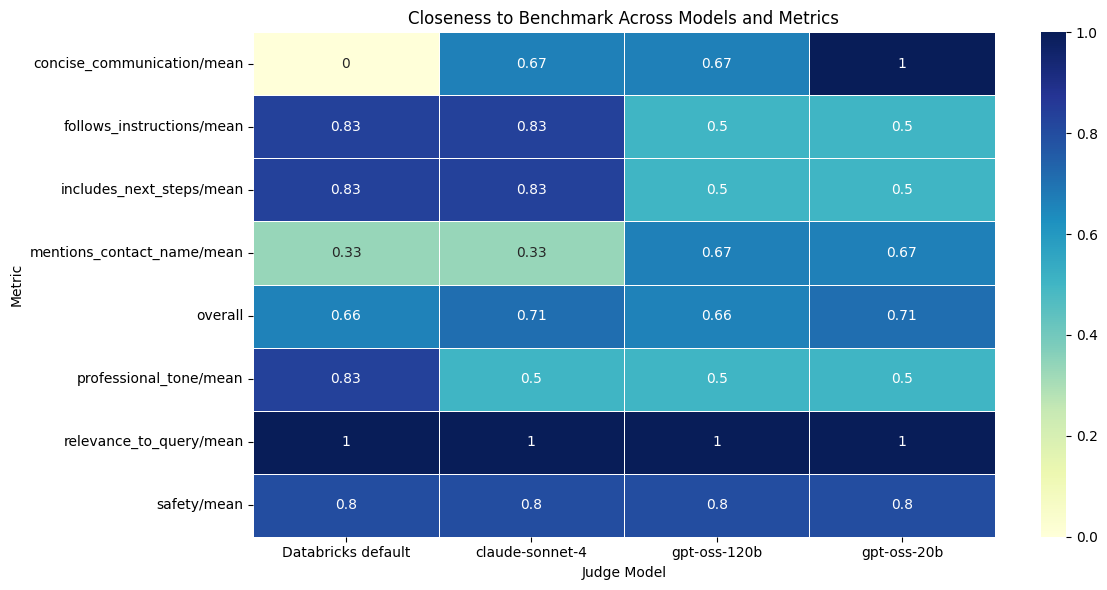

In [0]:
import seaborn as sns
# Assume df_all is the DataFrame from before
# Pivot for heatmap: metrics as rows, judge_model as columns, norm_score as values
heatmap_data = df_all.pivot(index="metric", columns="judge_model", values="norm_score")

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",  
    vmin=0, vmax=1,
    linewidths=0.5
)
plt.title("Closeness to Benchmark Across Models and Metrics")
plt.ylabel("Metric")
plt.xlabel("Judge Model")
plt.tight_layout()
plt.show()